
# Explore Data

This notebook helps explore Earth Engine export CSVs:
- Check required columns, missing data, basic stats
- See distribution by year/state/county
- Detect duplicate `.geo` locations
- Inspect feature–label correlations


In [ ]:
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from irr.constants import FEATURES, LABEL_COL

print("Expecting features:", len(FEATURES), FEATURES[:5], "...")
print("LABEL_COL:", LABEL_COL)

Expecting features: 64 ['A00', 'A01', 'A02', 'A03', 'A04'] ...
LABEL_COL: label


In [ ]:
# Configure
DATA_GLOB = "../raw_data/*.csv"        # e.g., "raw_data/*training*.csv"
SAMPLE_N = 20000                   
DETECT_YEAR_FROM_FILENAMES = True   # extract year 20xx from file names

Expecting features: 64 ['A00', 'A01', 'A02', 'A03', 'A04'] ...
LABEL_COL: label


In [28]:

# Find files
paths = sorted(glob.glob(DATA_GLOB))
if not paths:
    raise FileNotFoundError(f"No CSV files matched: {DATA_GLOB}")
print(f"Matched {len(paths)} file(s):")
for p in paths[:10]:
    print(" •", p)
if len(paths) > 10:
    print(" ...", len(paths)-10, "more")

# Load & concatenate
dfs = []
for p in paths:
    df = pd.read_csv(p)
    df["_source_path"] = p
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)
print(f"Combined shape: {raw.shape}")
display(raw.head(3))

Matched 20 file(s):
 • ../raw_data/ID_alphaearth_irrmapper_training_2018_random_n20000.csv
 • ../raw_data/ID_alphaearth_irrmapper_training_2019_random_n20000.csv
 • ../raw_data/ID_alphaearth_irrmapper_training_2020_random_n20000.csv
 • ../raw_data/ID_alphaearth_irrmapper_training_2021_random_n20000.csv
 • ../raw_data/ID_alphaearth_irrmapper_training_2022_random_n20000.csv
 • ../raw_data/MT_alphaearth_irrmapper_training_2018_random_n20000.csv
 • ../raw_data/MT_alphaearth_irrmapper_training_2019_random_n20000.csv
 • ../raw_data/MT_alphaearth_irrmapper_training_2020_random_n20000.csv
 • ../raw_data/MT_alphaearth_irrmapper_training_2021_random_n20000.csv
 • ../raw_data/MT_alphaearth_irrmapper_training_2022_random_n20000.csv
 ... 10 more
Combined shape: (389104, 74)


,system:index,A00,A01,A02,A03,A04,A05,A06,A07,A08,...,A63,cdl_code,county,county_fips,county_name,label,state,year,.geo,_source_path
0,0,0.119093,-0.007443,-0.075356,-0.012057,0.267958,0.135886,0.186082,0.004983,-0.075356,...,0.093564,176,<Feature>,21,Boundary,0,ID,2018,"{""type"":""Point"",""coordinates"":[-116.2773266337...",../raw_data/ID_alphaearth_irrmapper_training_2...
1,1,0.062991,-0.113741,-0.079723,0.108512,0.084214,-0.093564,0.015748,0.166336,0.062991,...,0.012057,142,<Feature>,49,Idaho,0,ID,2018,"{""type"":""Point"",""coordinates"":[-115.1124261163...",../raw_data/ID_alphaearth_irrmapper_training_2...
2,2,0.153787,-0.066990,-0.124567,0.019931,0.103406,0.027128,0.038447,0.214133,0.007443,...,-0.022207,142,<Feature>,15,Boise,0,ID,2018,"{""type"":""Point"",""coordinates"":[-116.1027591006...",../raw_data/ID_alphaearth_irrmapper_training_2...


In [31]:

missing = [c for c in FEATURES + [LABEL_COL] if c not in raw.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# na checks
na_counts = raw[FEATURES + [LABEL_COL]].isna().sum().sort_values(ascending=False)
print("Top missing counts:")
display(na_counts.head(15))

# Make a clean df for metrics
df = raw.dropna(subset=FEATURES + [LABEL_COL]).copy()

# Ensure label is 0/1
df[LABEL_COL] = (pd.to_numeric(df[LABEL_COL], errors="coerce").fillna(0) > 0).astype(int)
print(f"After dropna on features+label: {df.shape}")


Top missing counts:


A00    0
A33    0
A35    0
A36    0
A37    0
A38    0
A39    0
A40    0
A41    0
A42    0
A43    0
A44    0
A45    0
A46    0
A47    0
dtype: int64

After dropna on features+label: (389104, 74)


In [30]:
# if we need to reduce size for speed
if SAMPLE_N is not None and len(df) > SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=88).reset_index(drop=True)
    print(f"Downsampled to {len(df):,} rows for speed.")


Downsampled to 20,000 rows for speed.


In [32]:
# gets year from filename if missing
if "year" not in df.columns and DETECT_YEAR_FROM_FILENAMES:
    years = df["_source_path"].astype(str).apply(lambda s: int(re.search(r"20\d{2}", s).group()) if re.search(r"20\d{2}", s) else -1)
    df["year"] = years
    print("Added 'year' column from filenames.")
    
print("Columns:", list(df.columns)[:15], "...")


Columns: ['system:index', 'A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13'] ...


Total rows: 389,104 | 0s: 370,726 | 1s: 18,378 | Pos rate=4.723%


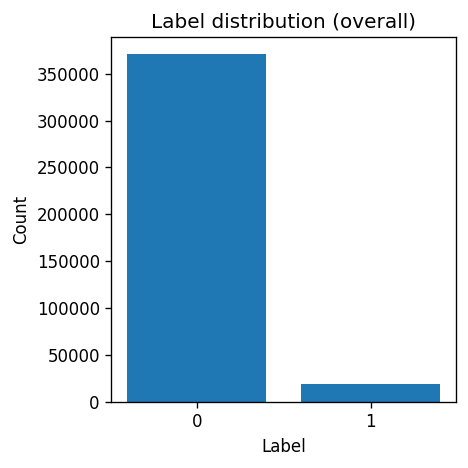

In [33]:
# Overall label distribution
vc = df[LABEL_COL].value_counts().sort_index()
n0 = int(vc.get(0, 0))
n1 = int(vc.get(1, 0))
p1 = n1 / max(n0+n1, 1)
print(f"Total rows: {len(df):,} | 0s: {n0:,} | 1s: {n1:,} | Pos rate={p1:.3%}")

plt.figure(figsize=(4,4), dpi=120)
plt.bar(["0","1"], [n0, n1])
plt.title("Label distribution (overall)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


label,0,1
year,,
2018,74126,3769
2019,73930,3782
2020,74070,3769
2021,74409,3452
2022,74191,3606


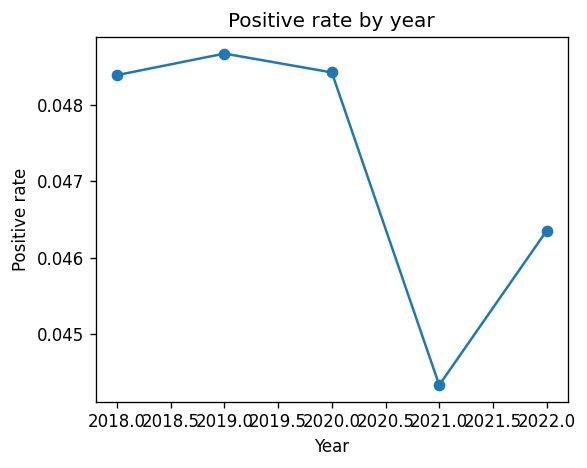

In [49]:
# By year 
if "year" in df.columns:
    by_year = df.groupby("year")[LABEL_COL].value_counts().unstack(fill_value=0).sort_index()
    display(by_year.head(10))
    
    plt.figure(figsize=(5,4), dpi=120)
    by_year_ratio = (by_year[1] / (by_year[0] + by_year[1]).replace(0, np.nan)).fillna(0)
    plt.plot(by_year_ratio.index.values, by_year_ratio.values, marker="o")
    plt.xlabel("Year")
    plt.ylabel("Positive rate")
    plt.title("Positive rate by year")
    plt.tight_layout()
    plt.show()
else:
    print("No 'year' column; skipping year breakdown.")


label,0,1
state,,
ID,90044,6708
MT,97459,2538
OR,93780,3748
WA,89443,5384


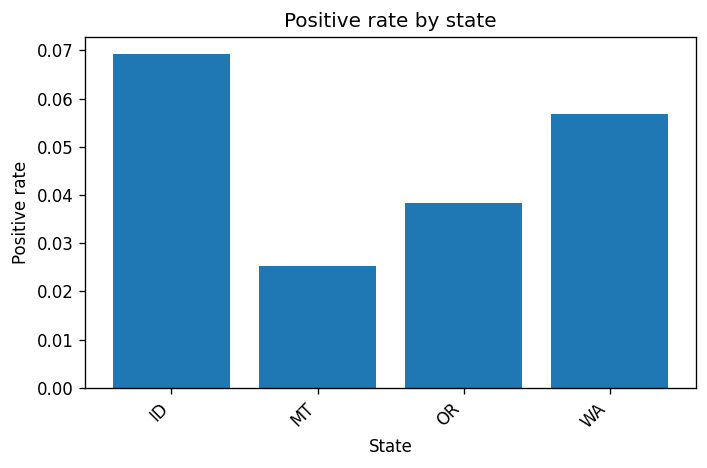

In [40]:

# By state (if present)
if "state" in df.columns:
    by_state = df.groupby("state")[LABEL_COL].value_counts().unstack(fill_value=0).sort_index()
    display(by_state)
    
    plt.figure(figsize=(6,4), dpi=120)
    pos_rate = (by_state[1] / (by_state[0] + by_state[1]).replace(0, np.nan)).fillna(0)
    plt.bar(pos_rate.index, pos_rate.values)
    plt.xlabel("State")
    plt.ylabel("Positive rate")
    plt.title("Positive rate by state")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No 'state' column; skipping state breakdown.")


label,0,1
county_name,,
Harney,10275,230
Malheur,10090,322
Idaho,10172,40
Lake,9622,338
Owyhee,8351,601
Grant,7183,1300
Custer,8178,147
Lincoln,7978,290
Valley,7682,63


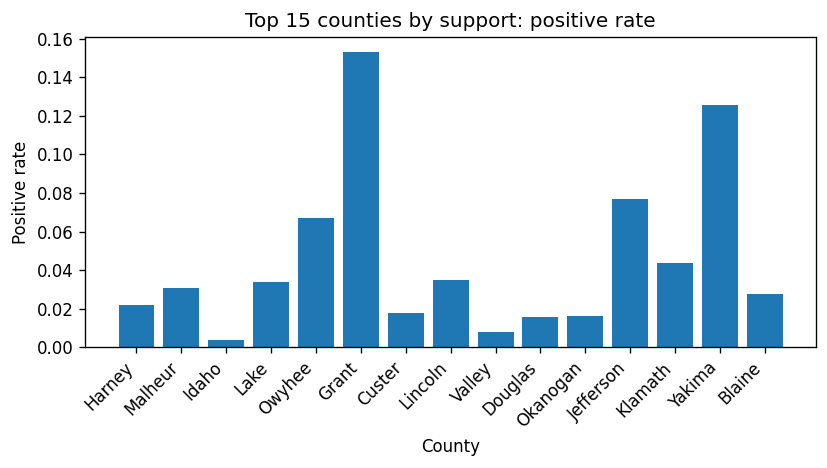

In [50]:

# By county
county_col = None
for cand in ["county_name", "county_fips"]:
    if cand in df.columns:
        county_col = cand
        break

if county_col:
    by_county = df.groupby(county_col)[LABEL_COL].value_counts().unstack(fill_value=0)
    # Show top 15 counties by support
    by_county["support"] = by_county[0] + by_county[1]
    top = by_county.sort_values("support", ascending=False).head(15)
    display(top.drop(columns=["support"]))
    
    plt.figure(figsize=(7,4), dpi=120)
    pos_rate_cnty = (top[1] / (top[0] + top[1]).replace(0, np.nan)).fillna(0)
    plt.bar(pos_rate_cnty.index.astype(str), pos_rate_cnty.values)
    plt.xlabel("County")
    plt.ylabel("Positive rate")
    plt.title("Top 15 counties by support: positive rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No county column found; skipping county breakdown.")


In [43]:
# Duplicate check by '.geo'
if ".geo" in df.columns:
    geo = df[".geo"].astype(str)
    n_unique = geo.nunique(dropna=False)
    dup_rate = 1.0 - (n_unique / len(df)) if len(df) else 0.0
    print(f"Unique .geo: {n_unique:,} / {len(df):,} rows | duplicate rate: {dup_rate:.2%}")
else:
    print("No '.geo' column; skipping duplicate .geo check.")

Unique .geo: 389,104 / 389,104 rows | duplicate rate: 0.00%


In [44]:
# Summary stats
feat_df = df[FEATURES].astype(float)
desc = feat_df.describe().T  # count, mean, std, min, 25%, 50%, 75%, max
display(desc.head(10))
print(f"(Features table length: {len(desc)})")


,count,mean,std,min,25%,50%,75%,max
A00,389104.0,0.082594,0.077478,-0.318893,0.038447,0.088827,0.135886,0.336855
A01,389104.0,-0.053563,0.096764,-0.465606,-0.124567,-0.059116,0.017778,0.292872
A02,389104.0,-0.061716,0.083464,-0.383914,-0.119093,-0.066990,-0.007443,0.336855
A03,389104.0,-0.048772,0.075970,-0.413626,-0.098424,-0.048228,0.003014,0.236463
A04,389104.0,0.109424,0.084235,-0.206936,0.041584,0.108512,0.179377,0.355309
A05,389104.0,0.028315,0.110458,-0.374256,-0.048228,0.027128,0.103406,0.383914
A06,389104.0,0.036181,0.082895,-0.301423,-0.017778,0.029773,0.084214,0.393695
A07,389104.0,0.054555,0.118883,-0.301423,-0.041584,0.048228,0.153787,0.413626
A08,389104.0,0.031362,0.103663,-0.393695,-0.035433,0.027128,0.098424,0.383914
A09,389104.0,-0.000048,0.085093,-0.413626,-0.051734,0.006151,0.059116,0.383914


(Features table length: 64)


Top + correlations:


,A51,A35,A46,A06,A48,A13,A47,A26,A02,A49
corr,0.254117,0.245522,0.244282,0.223688,0.216976,0.199806,0.194679,0.19325,0.191486,0.186324


Top - correlations:


,A62,A08,A61,A16,A09,A00,A25,A29,A45,A30
corr,-0.212634,-0.213347,-0.224738,-0.228392,-0.243871,-0.249138,-0.30607,-0.353989,-0.358608,-0.40621


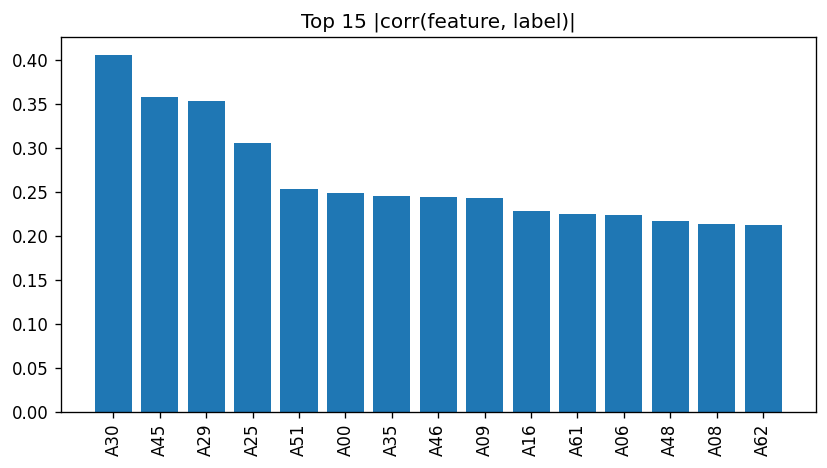

In [51]:
# Feature–label pearson correlation
label = df[LABEL_COL].astype(float)
corr = feat_df.corrwith(label).sort_values(ascending=False)
top_pos = corr.head(10)
top_neg = corr.tail(10)

print("Top + correlations:")
display(top_pos.to_frame("corr").T)
print("Top - correlations:")
display(top_neg.to_frame("corr").T)

# Bar of top |corr|
top_abs = corr.abs().sort_values(ascending=False).head(15)
plt.figure(figsize=(7,4), dpi=120)
plt.bar(top_abs.index, top_abs.values)
plt.title("Top 15 |corr(feature, label)|")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


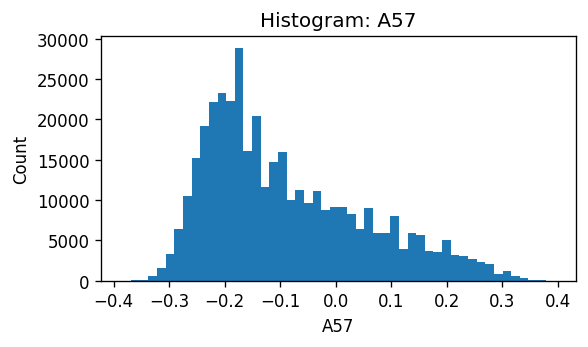

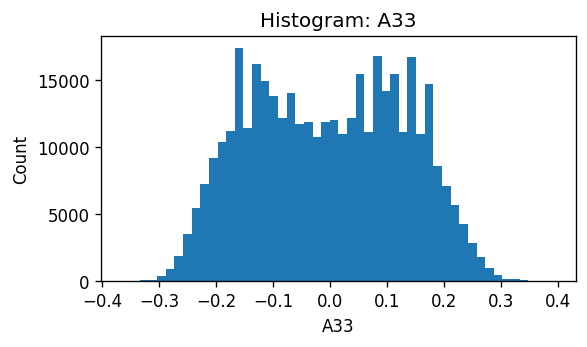

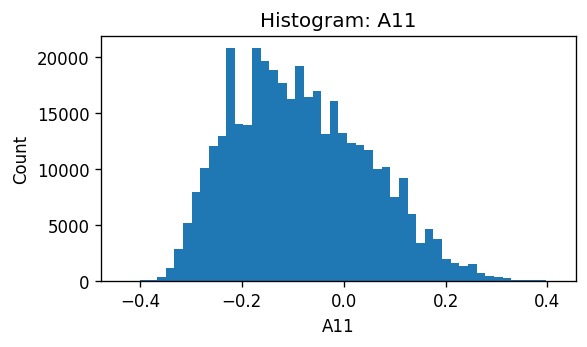

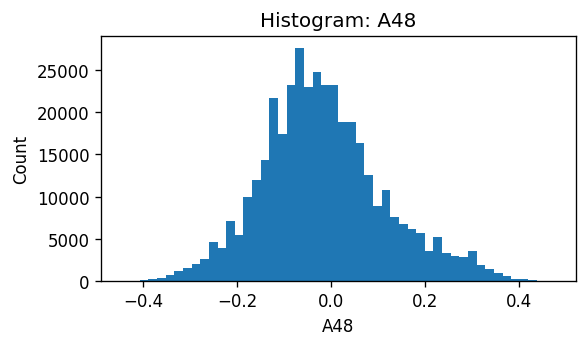

In [46]:
# histograms of top variance features
variances = feat_df.var().sort_values(ascending=False)
for f in variances.head(4).index:
    plt.figure(figsize=(5,3), dpi=120)
    plt.hist(feat_df[f].values, bins=50)
    plt.title(f"Histogram: {f}")
    plt.xlabel(f)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
